# PDEformer Finetuning Demo: Raw vs Finetuned

This notebook compares the pretrained PDEformer-L checkpoint against finetuned checkpoints for several demo equations.

Each equation is configured once in the `DEMOS` dictionary below. The shared helpers then render the logged finetuning curve, run a live held-out raw-vs-finetuned evaluation, and plot one representative sample.

The default entries cover Burgers2D-viscous, generated 2D Allen-Cahn, generated 2D Gray-Scott, and generated 2D Oldroyd-B/FENE-style viscoelastic flow. Add another `DemoEquation` entry to extend the notebook to a new finetuning run.


In [1]:
from dataclasses import dataclass, replace
from pathlib import Path
import csv
import gc

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from src import load_config, get_model
from src.core.metric import calculate_l2_error
from src.data import load_dataset, split_data_tuple
from src.torch_compat import context


@dataclass(frozen=True)
class DemoEquation:
    key: str
    title: str
    config_path: Path
    run_dir: Path
    finetuned_ckpt: Path
    result_csv: Path
    plot_sample_index: int = 0
    plot_time_index: int = -1
    var_index: int = 0
    required: bool = True


PRETRAINED_CKPT = Path("model-L.pt")
DEMOS = {
    "burgers2d_viscous": DemoEquation(
        key="burgers2d_viscous",
        title="Burgers2D-viscous",
        config_path=Path("configs/finetune/burgers2d_viscous_model-L.yaml"),
        run_dir=Path("exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51"),
        finetuned_ckpt=Path("exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51/ckpt/model_best.ckpt"),
        result_csv=Path("exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51/table/result.csv"),
    ),
    "allen_cahn2d": DemoEquation(
        key="allen_cahn2d",
        title="Allen-Cahn 2D",
        config_path=Path("configs/finetune/allen_cahn2d_model-L.yaml"),
        run_dir=Path("exp/finetune/allen_cahn2d/model-L/2026-06-17-19-15-54"),
        finetuned_ckpt=Path("exp/finetune/allen_cahn2d/model-L/2026-06-17-19-15-54/ckpt/model_best.ckpt"),
        result_csv=Path("exp/finetune/allen_cahn2d/model-L/2026-06-17-19-15-54/table/result.csv"),
    ),
    "grayscott2d": DemoEquation(
        key="grayscott2d",
        title="Gray-Scott 2D",
        config_path=Path("configs/finetune/grayscott2d_model-L.yaml"),
        run_dir=Path("exp/finetune/grayscott2d/model-L/latest"),
        finetuned_ckpt=Path("exp/finetune/grayscott2d/model-L/latest/ckpt/model_best.ckpt"),
        result_csv=Path("exp/finetune/grayscott2d/model-L/latest/table/result.csv"),
        required=False,
    ),
    "viscoelastic2d": DemoEquation(
        key="viscoelastic2d",
        title="Oldroyd-B/FENE-style 2D",
        config_path=Path("configs/finetune/viscoelastic2d_model-L.yaml"),
        run_dir=Path("exp/finetune/viscoelastic2d/model-L/latest"),
        finetuned_ckpt=Path("exp/finetune/viscoelastic2d/model-L/latest/ckpt/model_best.ckpt"),
        result_csv=Path("exp/finetune/viscoelastic2d/model-L/latest/table/result.csv"),
        required=False,
    ),
}

DEVICE_TARGET = "CPU"
MAX_EVAL_BATCHES = None  # set to an integer for a quicker smoke demo

context.set_context(mode=context.PYNATIVE_MODE, device_target=DEVICE_TARGET)


def demo_paths(demo):
    return [demo.config_path, demo.finetuned_ckpt, demo.result_csv]


def missing_demo_paths(demo):
    return [path for path in demo_paths(demo) if not path.exists()]


def with_latest_run(demo):
    if demo.run_dir.name != "latest" or not demo.run_dir.parent.exists():
        return demo
    run_dirs = sorted(
        [path for path in demo.run_dir.parent.iterdir() if path.is_dir()],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    for run_dir in run_dirs:
        candidate = replace(
            demo,
            run_dir=run_dir,
            finetuned_ckpt=run_dir / "ckpt/model_best.ckpt",
            result_csv=run_dir / "table/result.csv",
        )
        if not missing_demo_paths(candidate):
            return candidate
    return demo


DEMOS = {key: with_latest_run(demo) for key, demo in DEMOS.items()}


def validate_demo_paths(demos):
    paths = [PRETRAINED_CKPT]
    for demo in demos.values():
        if demo.required:
            paths.extend(demo_paths(demo))
    missing = [path for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing required demo artifact(s): " + ", ".join(map(str, missing)))


def require_demo_artifacts(demo):
    missing = missing_demo_paths(demo)
    if missing:
        raise FileNotFoundError("Missing demo artifact(s): " + ", ".join(map(str, missing)))


validate_demo_paths(DEMOS)

print(f"Raw checkpoint: {PRETRAINED_CKPT}")
for demo in DEMOS.values():
    status = "ready" if not missing_demo_paths(demo) else "pending artifacts"
    print(f"{demo.title}: {status}; config={demo.config_path}, finetuned={demo.finetuned_ckpt}")


/mnt/data/home/arjun/pdeformer-2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw checkpoint: model-L.pt
Burgers2D-viscous: ready; config=configs/finetune/burgers2d_viscous_model-L.yaml, finetuned=exp/finetune/burgers2d_viscous/model-L/2026-06-16-22-36-51/ckpt/model_best.ckpt
Allen-Cahn 2D: ready; config=configs/finetune/allen_cahn2d_model-L.yaml, finetuned=exp/finetune/allen_cahn2d/model-L/2026-06-17-19-15-54/ckpt/model_best.ckpt
Gray-Scott 2D: ready; config=configs/finetune/grayscott2d_model-L.yaml, finetuned=exp/finetune/grayscott2d/model-L/2026-06-25-14-55-03/ckpt/model_best.ckpt
Oldroyd-B/FENE-style 2D: ready; config=configs/finetune/viscoelastic2d_model-L.yaml, finetuned=exp/finetune/viscoelastic2d/model-L/2026-06-25-16-33-02/ckpt/model_best.ckpt


## Logged Finetuning Curve

The training script evaluates before any updates at epoch 0, so the first point is the raw pretrained model. Later points show the finetuned model during training.


| epoch | test_l2_mean | test_l2_max | train_l2_mean |
| --- | --- | --- | --- |
| 0 | 0.267256 | 0.543832 | 0.25704 |
| 5 | 0.171196 | 0.386773 | 0.11507 |
| 10 | 0.160805 | 0.365923 | 0.0813198 |
| 15 | 0.157565 | 0.360755 | 0.066146 |
| 20 | 0.16127 | 0.351128 | 0.0678925 |

| model | epoch | test_l2_mean | relative_improvement |
| --- | --- | --- | --- |
| raw pretrained | 0 | 0.267256 | 0 |
| best finetuned | 15 | 0.157565 | 0.410433 |

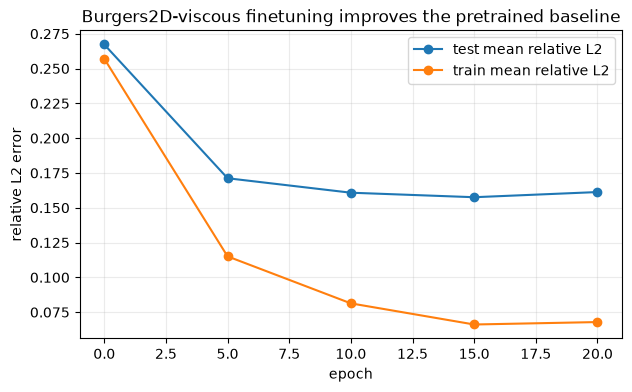

In [2]:
def read_metric_history(csv_path, metric_map):
    history_by_epoch = {}
    with open(csv_path, newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            for name, col in metric_map.items():
                step_col = f"{col} step"
                if row.get(col) and row.get(step_col):
                    epoch = float(row[step_col])
                    history_by_epoch.setdefault(epoch, {"epoch": epoch})[name] = float(row[col])
    return [history_by_epoch[key] for key in sorted(history_by_epoch)]


def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        values = []
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, float):
                values.append(f"{value:.6g}")
            else:
                values.append(str(value))
        body.append("| " + " | ".join(values) + " |")
    return "\n".join([header, sep] + body)


METRIC_COLS = {
    "test_l2_mean": "test_all_all/l2_error_mean",
    "test_l2_max": "test_all_all/l2_error_max",
    "train_l2_mean": "train_all_all/l2_error_mean",
}


def summarize_metric_history(history):
    raw_logged = history[0]
    best_logged = min(history, key=lambda row: row["test_l2_mean"])
    return [
        {
            "model": "raw pretrained",
            "epoch": int(raw_logged["epoch"]),
            "test_l2_mean": raw_logged["test_l2_mean"],
            "relative_improvement": 0.0,
        },
        {
            "model": "best finetuned",
            "epoch": int(best_logged["epoch"]),
            "test_l2_mean": best_logged["test_l2_mean"],
            "relative_improvement": 1 - best_logged["test_l2_mean"] / raw_logged["test_l2_mean"],
        },
    ]


def plot_metric_history(demo, history):
    epochs = [row["epoch"] for row in history]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs, [row["test_l2_mean"] for row in history], marker="o", label="test mean relative L2")
    if all("train_l2_mean" in row for row in history):
        ax.plot(epochs, [row["train_l2_mean"] for row in history], marker="o", label="train mean relative L2")
    ax.set_xlabel("epoch")
    ax.set_ylabel("relative L2 error")
    ax.set_title(f"{demo.title} finetuning improves the pretrained baseline")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()


def show_metric_history(demo):
    require_demo_artifacts(demo)
    history = read_metric_history(demo.result_csv, METRIC_COLS)
    display(Markdown(markdown_table(history, ["epoch", "test_l2_mean", "test_l2_max", "train_l2_mean"])))
    summary = summarize_metric_history(history)
    display(Markdown(markdown_table(summary, ["model", "epoch", "test_l2_mean", "relative_improvement"])))
    plot_metric_history(demo, history)
    return history, summary


burgers_history, burgers_summary = show_metric_history(DEMOS["burgers2d_viscous"])


## Live Held-Out Evaluation

This section reloads the same test loader twice and scores the raw and finetuned checkpoints on identical samples. Alongside relative L2, it reports a physics residual RMAE in the style of Bastek et al.: the mean absolute PDE residual of the model output. The Gray-Scott and viscoelastic live tables also report VRMSE. These generated demo equations use periodic grids, so the residual below contains the PDE terms and uses periodic finite differences rather than a separate boundary-condition term.


In [3]:
def make_eval_config(demo, checkpoint_path):
    cfg = load_config(str(demo.config_path))
    cfg.model.load_ckpt = str(checkpoint_path)
    cfg.data.num_workers = 0
    cfg.eval.plot_num_per_type = 0
    return cfg


def get_test_items(config):
    dataset_train, data_updater, train_iter_dict, test_iter_dict = load_dataset(config)
    try:
        items = []
        for pde_type, datasets in test_iter_dict.items():
            for datafile, pair in datasets.items():
                dataset_iter, dataset = pair
                items.append((pde_type, datafile, dataset_iter, dataset))
        return items, data_updater
    except Exception:
        data_updater("terminate")
        raise


def coefficient(data_info, *names):
    coef_dict = data_info.get("coef_dict", {})
    for name in names:
        if name in coef_dict:
            return float(coef_dict[name])
    raise KeyError(f"Could not find any coefficient from {names} in {coef_dict}")


def reshape_eval_field(field, coord, data_info):
    if "scatter_size" in data_info:
        raise ValueError("Residual RMAE is implemented for Cartesian-grid demo samples only.")
    n_t = data_info["n_t_grid"]
    n_x = data_info["n_x_grid"]
    n_y = data_info["n_y_grid"]
    field = field.reshape(n_t, n_x, n_y, -1)[..., 0]
    coord = coord.reshape(n_t, n_x, n_y, 4)
    return field.astype(np.float64), coord.astype(np.float64)


def grid_spacing(coord):
    t_values = coord[:, 0, 0, 0]
    x_values = coord[0, :, 0, 1]
    y_values = coord[0, 0, :, 2]
    return float(np.mean(np.diff(t_values))), float(np.mean(np.diff(x_values))), float(np.mean(np.diff(y_values)))


def ddx_periodic(field, dx):
    return (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2 * dx)


def ddy_periodic(field, dy):
    return (np.roll(field, -1, axis=2) - np.roll(field, 1, axis=2)) / (2 * dy)


def ddx_upwind(field, velocity, dx):
    backward = (field - np.roll(field, 1, axis=1)) / dx
    forward = (np.roll(field, -1, axis=1) - field) / dx
    return np.where(velocity >= 0, backward, forward)


def ddy_upwind(field, velocity, dy):
    backward = (field - np.roll(field, 1, axis=2)) / dy
    forward = (np.roll(field, -1, axis=2) - field) / dy
    return np.where(velocity >= 0, backward, forward)


def lap_periodic(field, dx, dy):
    return (
        (np.roll(field, -1, axis=1) - 2 * field + np.roll(field, 1, axis=1)) / dx**2
        + (np.roll(field, -1, axis=2) - 2 * field + np.roll(field, 1, axis=2)) / dy**2
    )


def central_dt(field, dt):
    if field.shape[0] < 3:
        raise ValueError("Need at least three saved time levels for central-difference residuals.")
    return (field[2:] - field[:-2]) / (2 * dt)


def allen_cahn_residual_rmae(field, coord, data_info):
    epsilon = coefficient(data_info, r"\epsilon", "epsilon")
    rho = coefficient(data_info, r"\rho", "rho")
    dt, dx, dy = grid_spacing(coord)
    u_mid = field[1:-1]
    residual = central_dt(field, dt) - epsilon * lap_periodic(u_mid, dx, dy) - rho * (u_mid - u_mid**3)
    return float(np.mean(np.abs(residual)))


def grayscott_residual_rmae(fields_by_var, coord, data_info):
    missing = [idx for idx in (0, 1) if idx not in fields_by_var]
    if missing:
        raise ValueError(f"Need paired u,v outputs for Gray-Scott residual; missing variable indices {missing}.")
    du = coefficient(data_info, r"D_u", "D_u", "du")
    dv = coefficient(data_info, r"D_v", "D_v", "dv")
    feed = coefficient(data_info, r"F", "F", "feed")
    kill = coefficient(data_info, r"k", "k", "kill")
    dt, dx, dy = grid_spacing(coord)
    u = fields_by_var[0]
    v = fields_by_var[1]
    u_mid = u[1:-1]
    v_mid = v[1:-1]
    uv2 = u_mid * v_mid * v_mid
    residual_u = central_dt(u, dt) - du * lap_periodic(u_mid, dx, dy) + uv2 - feed * (1 - u_mid)
    residual_v = central_dt(v, dt) - dv * lap_periodic(v_mid, dx, dy) - uv2 + (feed + kill) * v_mid
    return float(np.mean(np.abs(np.concatenate([residual_u.ravel(), residual_v.ravel()]))))


def viscoelastic_residual_rmae(fields_by_var, coord, data_info):
    missing = [idx for idx in range(5) if idx not in fields_by_var]
    if missing:
        raise ValueError(f"Need u,v,Cxx,Cxy,Cyy outputs for viscoelastic residual; missing variable indices {missing}.")
    nu = coefficient(data_info, r"\nu", "nu", "viscosity")
    beta = coefficient(data_info, r"\beta", "beta", "polymer_coupling")
    inv_lam = coefficient(data_info, r"\lambda^{-1}", "inv_relaxation_time")
    kappa = coefficient(data_info, r"\kappa", "kappa", "stress_diffusivity")
    chi = coefficient(data_info, r"\chi", "chi", "fene_strength")
    dt, dx, dy = grid_spacing(coord)
    u, v, cxx, cxy, cyy = [fields_by_var[idx] for idx in range(5)]
    u_mid = u[1:-1]
    v_mid = v[1:-1]
    cxx_mid = cxx[1:-1]
    cxy_mid = cxy[1:-1]
    cyy_mid = cyy[1:-1]

    ux = ddx_periodic(u_mid, dx)
    uy = ddy_periodic(u_mid, dy)
    vx = ddx_periodic(v_mid, dx)
    vy = ddy_periodic(v_mid, dy)
    cxx_x = ddx_periodic(cxx_mid, dx)
    cxx_y = ddy_periodic(cxx_mid, dy)
    cxy_x = ddx_periodic(cxy_mid, dx)
    cxy_y = ddy_periodic(cxy_mid, dy)
    cyy_x = ddx_periodic(cyy_mid, dx)
    cyy_y = ddy_periodic(cyy_mid, dy)
    trace_shift = cxx_mid + cyy_mid - 2
    fene_correction = chi * trace_shift

    residual_u = (
        central_dt(u, dt)
        + u_mid * ddx_upwind(u_mid, u_mid, dx)
        + v_mid * ddy_upwind(u_mid, v_mid, dy)
        - nu * lap_periodic(u_mid, dx, dy)
        - beta * (cxx_x + cxy_y)
    )
    residual_v = (
        central_dt(v, dt)
        + u_mid * ddx_upwind(v_mid, u_mid, dx)
        + v_mid * ddy_upwind(v_mid, v_mid, dy)
        - nu * lap_periodic(v_mid, dx, dy)
        - beta * (cxy_x + cyy_y)
    )
    residual_cxx = (
        central_dt(cxx, dt)
        + u_mid * ddx_upwind(cxx_mid, u_mid, dx)
        + v_mid * ddy_upwind(cxx_mid, v_mid, dy)
        - 2 * (cxx_mid * ux + cxy_mid * uy)
        + inv_lam * (cxx_mid - 1 + fene_correction * cxx_mid)
        - kappa * lap_periodic(cxx_mid, dx, dy)
    )
    residual_cxy = (
        central_dt(cxy, dt)
        + u_mid * ddx_upwind(cxy_mid, u_mid, dx)
        + v_mid * ddy_upwind(cxy_mid, v_mid, dy)
        - (cxx_mid * vx + cxy_mid * vy + cxy_mid * ux + cyy_mid * uy)
        + inv_lam * (cxy_mid + fene_correction * cxy_mid)
        - kappa * lap_periodic(cxy_mid, dx, dy)
    )
    residual_cyy = (
        central_dt(cyy, dt)
        + u_mid * ddx_upwind(cyy_mid, u_mid, dx)
        + v_mid * ddy_upwind(cyy_mid, v_mid, dy)
        - 2 * (cxy_mid * vx + cyy_mid * vy)
        + inv_lam * (cyy_mid - 1 + fene_correction * cyy_mid)
        - kappa * lap_periodic(cyy_mid, dx, dy)
    )
    residuals = [residual_u, residual_v, residual_cxx, residual_cxy, residual_cyy]
    return float(np.mean(np.abs(np.concatenate([residual.ravel() for residual in residuals]))))


def burgers_residual_rmae(fields_by_var, coord, data_info):
    missing = [idx for idx in (0, 1) if idx not in fields_by_var]
    if missing:
        raise ValueError(f"Need paired u,v outputs for Burgers residual; missing variable indices {missing}.")
    nu = coefficient(data_info, r"\nu", "nu", "viscosity")
    dt, dx, dy = grid_spacing(coord)
    u = fields_by_var[0]
    v = fields_by_var[1]
    u_mid = u[1:-1]
    v_mid = v[1:-1]
    residual_u = (
        central_dt(u, dt)
        + u_mid * ddx_upwind(u_mid, u_mid, dx)
        + v_mid * ddy_upwind(u_mid, v_mid, dy)
        - nu * lap_periodic(u_mid, dx, dy)
    )
    residual_v = (
        central_dt(v, dt)
        + u_mid * ddx_upwind(v_mid, u_mid, dx)
        + v_mid * ddy_upwind(v_mid, v_mid, dy)
        - nu * lap_periodic(v_mid, dx, dy)
    )
    return float(np.mean(np.abs(np.concatenate([residual_u.ravel(), residual_v.ravel()]))))


def residual_rmae_for_group(pde_type, fields_by_var, coord, data_info):
    if pde_type in {"allen_cahn2d", "allen-cahn2d", "allen_cahn"}:
        return allen_cahn_residual_rmae(fields_by_var[0], coord, data_info)
    if pde_type in {"burgers2d_viscous", "burgers2d"}:
        return burgers_residual_rmae(fields_by_var, coord, data_info)
    if pde_type in {"grayscott2d", "gray_scott2d", "gray-scott2d"}:
        return grayscott_residual_rmae(fields_by_var, coord, data_info)
    if pde_type in {"viscoelastic2d", "oldroyd_b2d", "oldroyd-b2d", "fene2d", "fene-p2d"}:
        return viscoelastic_residual_rmae(fields_by_var, coord, data_info)
    raise NotImplementedError(f"Residual RMAE is not implemented for demo PDE type {pde_type!r}.")


def loader_size(dataset_iter):
    if hasattr(dataset_iter, "get_dataset_size"):
        return dataset_iter.get_dataset_size()
    if hasattr(dataset_iter, "__len__"):
        return len(dataset_iter)
    return None


def calculate_vrmse(pred, label):
    pred_arr = pred.asnumpy()
    label_arr = label.asnumpy()
    return np.sqrt(np.mean((pred_arr - label_arr) ** 2, axis=tuple(range(1, pred_arr.ndim))))


def evaluate_checkpoint(demo, checkpoint_path, keep_sample=False, sample_index=None):
    require_demo_artifacts(demo)
    cfg = make_eval_config(demo, checkpoint_path)
    test_items, data_updater = get_test_items(cfg)
    model = get_model(cfg)
    model.set_train(False)

    rows = []
    residual_groups = {}
    row_refs_by_group = {}
    sample = None
    sample_index = demo.plot_sample_index if sample_index is None else sample_index
    try:
        with torch.no_grad():
            checkpoint_label = Path(checkpoint_path).name
            item_bar = tqdm(test_items, desc=f"{demo.title} {checkpoint_label}", leave=True)
            for pde_type, datafile, dataset_iter, dataset in item_bar:
                item_bar.set_postfix_str(f"{pde_type}/{datafile}")
                batch_count = 0
                iterator = dataset_iter.create_tuple_iterator() if hasattr(dataset_iter, "create_tuple_iterator") else dataset_iter
                total_batches = loader_size(dataset_iter)
                if MAX_EVAL_BATCHES is not None and total_batches is not None:
                    total_batches = min(total_batches, MAX_EVAL_BATCHES)
                batch_desc = f"{checkpoint_label} {pde_type}/{datafile}"
                for data_tuple in tqdm(iterator, total=total_batches, desc=batch_desc, leave=False):
                    input_tuple, label, data_idx = split_data_tuple(data_tuple)
                    coord_batch = input_tuple[-1]
                    pred = model(*input_tuple)
                    l2 = calculate_l2_error(pred, label)
                    vrmse = calculate_vrmse(pred, label)
                    for i, value in enumerate(l2):
                        data_info = dataset.get_pde_info(int(data_idx[i]))
                        idx_pde = int(data_info.get("idx_pde", data_idx[i]))
                        idx_var = data_info.get("idx_var", 0)
                        idx_var = 0 if idx_var is None else int(idx_var)
                        row = {
                            "pde_type": pde_type,
                            "datafile": datafile,
                            "data_idx": int(data_idx[i]),
                            "idx_pde": idx_pde,
                            "idx_var": idx_var,
                            "relative_l2": float(value),
                            "vrmse": float(vrmse[i]),
                            "residual_rmae": np.nan,
                        }
                        rows.append(row)

                        try:
                            field, coord_grid = reshape_eval_field(
                                pred[i].asnumpy().astype(np.float32),
                                coord_batch[i].asnumpy().astype(np.float32),
                                data_info,
                            )
                        except ValueError:
                            continue
                        group_key = (pde_type, datafile, idx_pde)
                        group = residual_groups.setdefault(group_key, {
                            "pde_type": pde_type,
                            "coord": coord_grid,
                            "fields_by_var": {},
                            "data_info": data_info,
                        })
                        group["fields_by_var"][idx_var] = field
                        if idx_var == 0:
                            group["data_info"] = data_info
                        row_refs_by_group.setdefault(group_key, []).append(row)

                    if keep_sample and sample is None:
                        i = min(sample_index, label.shape[0] - 1)
                        sample = {
                            "pred": pred[i].asnumpy().astype(np.float32),
                            "label": label[i].asnumpy().astype(np.float32),
                            "coord": coord_batch[i].asnumpy().astype(np.float32),
                            "data_idx": int(data_idx[i]),
                            "data_info": dataset.get_pde_info(int(data_idx[i])),
                        }
                    batch_count += 1
                    if MAX_EVAL_BATCHES is not None and batch_count >= MAX_EVAL_BATCHES:
                        break

        for group_key, group in residual_groups.items():
            try:
                residual_rmae = residual_rmae_for_group(
                    group["pde_type"],
                    group["fields_by_var"],
                    group["coord"],
                    group["data_info"],
                )
            except (KeyError, ValueError, NotImplementedError) as err:
                print(f"Skipping residual RMAE for {group_key}: {err}")
                continue
            for row in row_refs_by_group[group_key]:
                row["residual_rmae"] = residual_rmae
    finally:
        data_updater("terminate")
        del model
        gc.collect()
    return rows, sample


def score_values(scores, metric):
    if metric == "residual_rmae":
        values_by_sample = {}
        for row in scores:
            value = row.get(metric, np.nan)
            if np.isfinite(value):
                key = (row["pde_type"], row["datafile"], row["idx_pde"])
                values_by_sample[key] = float(value)
        values = list(values_by_sample.values())
    else:
        values = [row[metric] for row in scores if np.isfinite(row.get(metric, np.nan))]
    return np.asarray(values, dtype=np.float32)


def describe_scores(scores, metric):
    arr = score_values(scores, metric)
    if arr.size == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "min": np.nan,
            "median": np.nan,
            "max": np.nan,
        }
    return {
        "count": int(arr.size),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "min": float(arr.min()),
        "median": float(np.median(arr)),
        "max": float(arr.max()),
    }


def score_summary_rows(raw_scores, finetuned_scores, include_vrmse=False):
    rows = []
    metrics = [("relative_l2", "relative L2"), ("residual_rmae", "residual RMAE")]
    if include_vrmse:
        metrics.insert(1, ("vrmse", "VRMSE"))
    for metric, label in metrics:
        raw_desc = describe_scores(raw_scores, metric)
        ft_desc = describe_scores(finetuned_scores, metric)
        for stat in ["count", "mean", "std", "min", "median", "max"]:
            rows.append({
                "metric": label,
                "stat": stat,
                "raw pretrained": raw_desc[stat],
                "finetuned": ft_desc[stat],
            })
        improvement = np.nan
        if np.isfinite(raw_desc["mean"]) and raw_desc["mean"] != 0 and np.isfinite(ft_desc["mean"]):
            improvement = 1 - ft_desc["mean"] / raw_desc["mean"]
        rows.append({
            "metric": label,
            "stat": "improvement_vs_raw",
            "raw pretrained": "",
            "finetuned": improvement,
        })
    return rows


def evaluate_demo(demo, keep_sample=True):
    raw_scores, raw_sample = evaluate_checkpoint(demo, PRETRAINED_CKPT, keep_sample=keep_sample)
    finetuned_scores, finetuned_sample = evaluate_checkpoint(demo, demo.finetuned_ckpt, keep_sample=keep_sample)
    include_vrmse = demo.key in {"grayscott2d", "viscoelastic2d"}
    display(Markdown(markdown_table(score_summary_rows(raw_scores, finetuned_scores, include_vrmse), ["metric", "stat", "raw pretrained", "finetuned"])))
    return raw_scores, raw_sample, finetuned_scores, finetuned_sample


burgers_raw_scores, burgers_raw_sample, burgers_finetuned_scores, burgers_finetuned_sample = evaluate_demo(DEMOS["burgers2d_viscous"])



Burgers2D-viscous model-L.pt:   0%|          | 0/1 [00:00<?, ?it/s, burgers2d_viscous/burgers2d_viscous]

Burgers2D-viscous model_best.ckpt: 100%|██████████| 1/1 [01:16<00:00, 76.14s/it, burgers2d_viscous/burgers2d_viscous]


| metric | stat | raw pretrained | finetuned |
| --- | --- | --- | --- |
| relative L2 | count | 16 | 16 |
| relative L2 | mean | 0.267256 | 0.157565 |
| relative L2 | std | 0.0898145 | 0.0765652 |
| relative L2 | min | 0.162583 | 0.0906784 |
| relative L2 | median | 0.25114 | 0.123855 |
| relative L2 | max | 0.543831 | 0.360755 |
| relative L2 | improvement_vs_raw |  | 0.410433 |
| residual RMAE | count | 8 | 8 |
| residual RMAE | mean | 0.076236 | 0.0501706 |
| residual RMAE | std | 0.016327 | 0.0162634 |
| residual RMAE | min | 0.0529853 | 0.0332287 |
| residual RMAE | median | 0.0736383 | 0.0477916 |
| residual RMAE | max | 0.11185 | 0.0880083 |
| residual RMAE | improvement_vs_raw |  | 0.341905 |

## One-Sample Visual Comparison

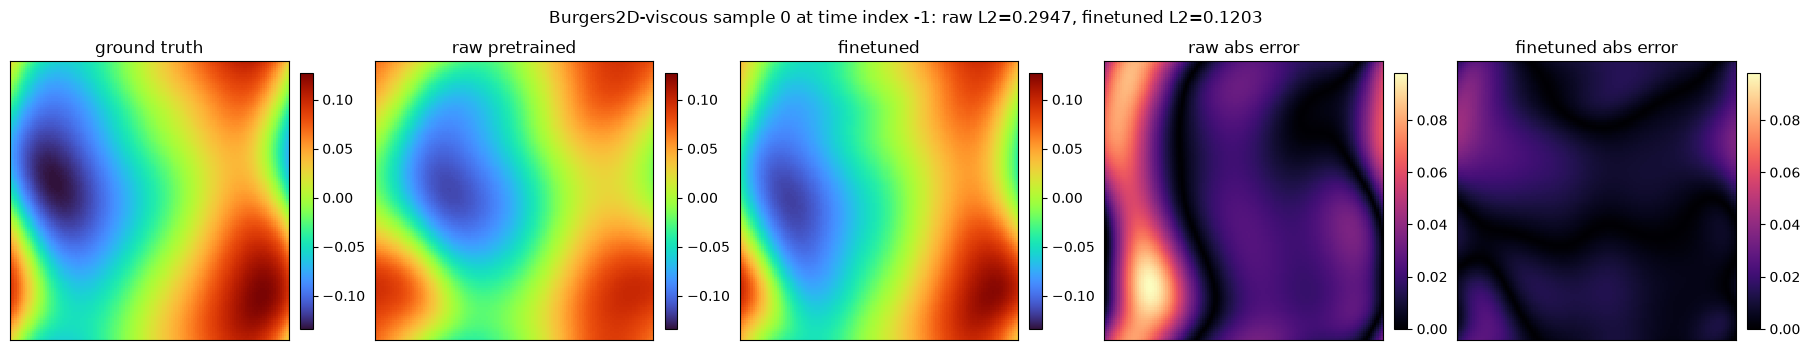

$u_t+uu_x+vu_y-\nu(u_{xx}+u_{yy})=0$
$v_t+uv_x+vv_y-\nu(v_{xx}+v_{yy})=0$


In [4]:
def reshape_sample(sample):
    info = sample["data_info"]
    n_vars = sample["label"].shape[-1]
    if "scatter_size" in info:
        raise ValueError("This visual helper expects Cartesian-grid samples, not scatter samples.")
    shape = (info["n_t_grid"], info["n_x_grid"], info["n_y_grid"], n_vars)
    label = sample["label"].reshape(shape)
    pred = sample["pred"].reshape(shape)
    coord = sample["coord"].reshape(shape[:-1] + (4,))
    return label, pred, coord, info


def sample_constancy_rows(sample, time_indices=None, atol=1e-7):
    label, pred, coord, info = reshape_sample(sample)
    var_idx = 0
    if time_indices is None:
        time_indices = [0, pred.shape[0] // 2, pred.shape[0] - 1]

    rows = []
    global_field = pred[..., var_idx]
    rows.append({
        "scope": "all times",
        "min": float(global_field.min()),
        "max": float(global_field.max()),
        "std": float(global_field.std()),
        "peak_to_peak": float(np.ptp(global_field)),
        "unique_values": int(np.unique(global_field).size),
        "constant_atol_1e-7": bool(np.allclose(global_field, global_field.flat[0], rtol=0.0, atol=atol)),
    })
    for time_idx in time_indices:
        field = pred[time_idx, :, :, var_idx]
        rows.append({
            "scope": f"time index {time_idx}",
            "min": float(field.min()),
            "max": float(field.max()),
            "std": float(field.std()),
            "peak_to_peak": float(np.ptp(field)),
            "unique_values": int(np.unique(field).size),
            "constant_atol_1e-7": bool(np.allclose(field, field.flat[0], rtol=0.0, atol=atol)),
        })
    return rows


def display_constancy_check(sample):
    columns = ["scope", "min", "max", "std", "peak_to_peak", "unique_values", "constant_atol_1e-7"]
    rows = sample_constancy_rows(sample)
    display(Markdown(markdown_table(rows, columns)))
    return rows


def plot_sample_comparison(demo, raw_sample, finetuned_sample, print_coefficients=False):
    label, raw_pred, coord, info = reshape_sample(raw_sample)
    _, ft_pred, _, _ = reshape_sample(finetuned_sample)

    var_idx = demo.var_index
    time_idx = demo.plot_time_index
    x = coord[time_idx, :, :, 1]
    y = coord[time_idx, :, :, 2]
    truth = label[time_idx, :, :, var_idx]
    raw = raw_pred[time_idx, :, :, var_idx]
    ft = ft_pred[time_idx, :, :, var_idx]

    fields = [truth, raw, ft, np.abs(raw - truth), np.abs(ft - truth)]
    titles = ["ground truth", "raw pretrained", "finetuned", "raw abs error", "finetuned abs error"]

    vmin = min(truth.min(), raw.min(), ft.min())
    vmax = max(truth.max(), raw.max(), ft.max())
    err_vmax = max(fields[3].max(), fields[4].max())

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), constrained_layout=True)
    for ax, field, title in zip(axes, fields, titles):
        if "error" in title:
            mesh = ax.pcolormesh(x, y, field, shading="auto", cmap="magma", vmin=0, vmax=err_vmax)
        else:
            mesh = ax.pcolormesh(x, y, field, shading="auto", cmap="turbo", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)

    raw_l2 = calculate_l2_error(torch.as_tensor(raw_sample["pred"])[None], torch.as_tensor(raw_sample["label"])[None])[0]
    ft_l2 = calculate_l2_error(torch.as_tensor(finetuned_sample["pred"])[None], torch.as_tensor(finetuned_sample["label"])[None])[0]
    fig.suptitle(
        f"{demo.title} sample {raw_sample['data_idx']} at time index {time_idx}: "
        f"raw L2={raw_l2:.4f}, finetuned L2={ft_l2:.4f}"
    )
    plt.show()

    print(info.get("pde_latex", ""))
    if print_coefficients:
        print(info.get("coef_dict", {}))


plot_sample_comparison(DEMOS["burgers2d_viscous"], burgers_raw_sample, burgers_finetuned_sample)


## Allen-Cahn Finetuning Demo

This section repeats the same raw-vs-finetuned comparison for the generated 2D Allen-Cahn reaction-diffusion experiment. The PDE is

$$u_t - \epsilon (u_{xx} + u_{yy}) - \rho (u - u^3) = 0,$$

with periodic boundaries and sample-dependent `epsilon` and `rho`.

| epoch | test_l2_mean | test_l2_max | train_l2_mean |
| --- | --- | --- | --- |
| 0 | 0.958658 | 0.998573 | 0.944399 |
| 5 | 0.804189 | 0.945344 | 0.760266 |
| 10 | 0.50641 | 0.765716 | 0.428614 |
| 15 | 0.336303 | 0.543442 | 0.275301 |
| 20 | 0.256661 | 0.435284 | 0.162549 |

| model | epoch | test_l2_mean | relative_improvement |
| --- | --- | --- | --- |
| raw pretrained | 0 | 0.958658 | 0 |
| best finetuned | 20 | 0.256661 | 0.73227 |

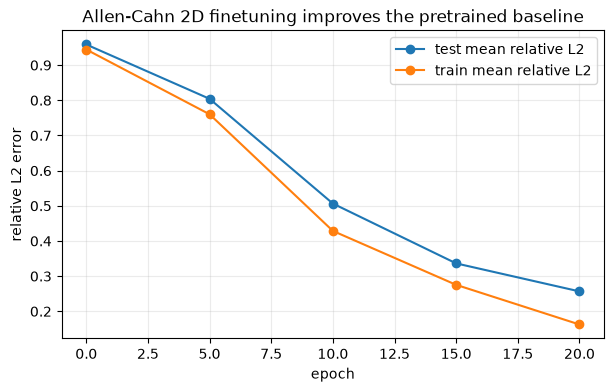

In [5]:
allen_demo = DEMOS["allen_cahn2d"]
allen_history, allen_summary = show_metric_history(allen_demo)


### Allen-Cahn Live Held-Out Evaluation

Run this cell when you want checkpoint-derived before/after numbers for Allen-Cahn, not only the logged CSV metrics. It reuses the shared helper functions and may take a few minutes on CPU.


In [6]:
allen_raw_scores, allen_raw_sample, allen_finetuned_scores, allen_finetuned_sample = evaluate_demo(allen_demo)

print("Raw Allen-Cahn pretrained prediction constancy check")
allen_constancy_rows = display_constancy_check(allen_raw_sample)
if all(row["constant_atol_1e-7"] for row in allen_constancy_rows):
    print("Conclusion: the raw pretrained prediction is constant to atol=1e-7 for the checked scopes.")
else:
    print("Conclusion: the raw pretrained prediction is not truly constant; it only appears low-contrast in the plot.")


Allen-Cahn 2D model-L.pt:   0%|          | 0/1 [00:00<?, ?it/s, allen_cahn2d/allen_cahn2d]

Allen-Cahn 2D model_best.ckpt: 100%|██████████| 1/1 [00:40<00:00, 40.05s/it, allen_cahn2d/allen_cahn2d]


| metric | stat | raw pretrained | finetuned |
| --- | --- | --- | --- |
| relative L2 | count | 8 | 8 |
| relative L2 | mean | 0.958658 | 0.256661 |
| relative L2 | std | 0.052799 | 0.144474 |
| relative L2 | min | 0.827078 | 0.0913505 |
| relative L2 | median | 0.969786 | 0.251627 |
| relative L2 | max | 0.998573 | 0.435285 |
| relative L2 | improvement_vs_raw |  | 0.73227 |
| residual RMAE | count | 8 | 8 |
| residual RMAE | mean | 0.19042 | 0.288898 |
| residual RMAE | std | 0.0565382 | 0.24885 |
| residual RMAE | min | 0.10037 | 0.0421381 |
| residual RMAE | median | 0.19399 | 0.143665 |
| residual RMAE | max | 0.276408 | 0.682172 |
| residual RMAE | improvement_vs_raw |  | -0.517159 |

Raw Allen-Cahn pretrained prediction constancy check


| scope | min | max | std | peak_to_peak | unique_values | constant_atol_1e-7 |
| --- | --- | --- | --- | --- | --- | --- |
| all times | -0.162366 | 0.197411 | 0.0377263 | 0.359777 | 130806 | False |
| time index 0 | -0.162366 | 0.197411 | 0.0843881 | 0.359777 | 16381 | False |
| time index 4 | -0.0330391 | 0.0105792 | 0.00946303 | 0.0436183 | 16376 | False |
| time index 7 | -0.0280924 | -0.0052301 | 0.00480476 | 0.0228623 | 16366 | False |

Conclusion: the raw pretrained prediction is not truly constant; it only appears low-contrast in the plot.


### Allen-Cahn One-Sample Visual Comparison

## Gray-Scott Finetuning Demo

This section is wired for the generated 2D Gray-Scott reaction-diffusion experiment. Generate data with `python3 scripts/generate_grayscott2d_data.py`, then finetune with `config_path=configs/finetune/grayscott2d_model-L.yaml python3 train.py`. The demo entry auto-resolves `exp/finetune/grayscott2d/model-L/latest` to the newest timestamped run with a checkpoint and result CSV. The PDE is

$$u_t-D_u(u_{xx}+u_{yy})+uv^2-F(1-u)=0,$$

$$v_t-D_v(v_{xx}+v_{yy})-uv^2+(F+k)v=0,$$

with periodic boundaries and sample-dependent `D_u`, `D_v`, `F`, and `k`.


| epoch | test_l2_mean | test_l2_max | train_l2_mean |
| --- | --- | --- | --- |
| 0 | 0.239366 | 0.423217 | 0.248861 |
| 5 | 0.117237 | 0.262719 | 0.106331 |
| 10 | 0.111793 | 0.256051 | 0.0976117 |
| 15 | 0.111322 | 0.255453 | 0.0939715 |
| 20 | 0.108852 | 0.252593 | 0.0894608 |

| model | epoch | test_l2_mean | relative_improvement |
| --- | --- | --- | --- |
| raw pretrained | 0 | 0.239366 | 0 |
| best finetuned | 20 | 0.108852 | 0.54525 |

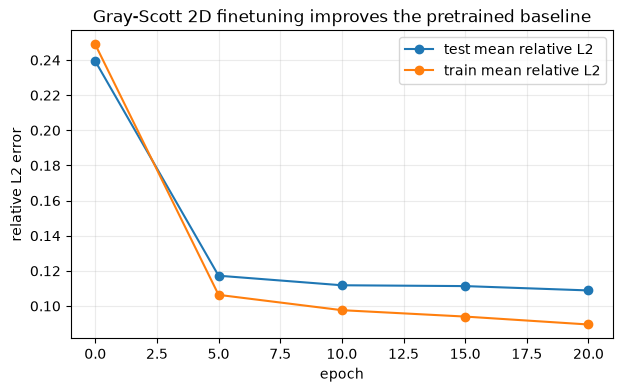

In [7]:
grayscott_demo = DEMOS["grayscott2d"]
grayscott_history, grayscott_summary = show_metric_history(grayscott_demo)


### Gray-Scott Live Held-Out Evaluation

Run this cell after the Gray-Scott finetune has produced a checkpoint and result CSV.


In [8]:
grayscott_raw_scores, grayscott_raw_sample, grayscott_finetuned_scores, grayscott_finetuned_sample = evaluate_demo(grayscott_demo)


Gray-Scott 2D model-L.pt:   0%|          | 0/1 [00:00<?, ?it/s, grayscott2d/grayscott2d]

Gray-Scott 2D model_best.ckpt: 100%|██████████| 1/1 [01:27<00:00, 88.00s/it, grayscott2d/grayscott2d]


| metric | stat | raw pretrained | finetuned |
| --- | --- | --- | --- |
| relative L2 | count | 16 | 16 |
| relative L2 | mean | 0.239366 | 0.108852 |
| relative L2 | std | 0.14376 | 0.0909615 |
| relative L2 | min | 0.0930325 | 0.0171818 |
| relative L2 | median | 0.225237 | 0.0833201 |
| relative L2 | max | 0.423216 | 0.252593 |
| relative L2 | improvement_vs_raw |  | 0.54525 |
| VRMSE | count | 16 | 16 |
| VRMSE | mean | 0.0587374 | 0.0163684 |
| VRMSE | std | 0.0337026 | 0.00393839 |
| VRMSE | min | 0.0211732 | 0.0102967 |
| VRMSE | median | 0.0594676 | 0.0155065 |
| VRMSE | max | 0.0958303 | 0.0232764 |
| VRMSE | improvement_vs_raw |  | 0.721329 |
| residual RMAE | count | 8 | 8 |
| residual RMAE | mean | 0.0340448 | 0.00900134 |
| residual RMAE | std | 0.00111521 | 0.000843048 |
| residual RMAE | min | 0.0327906 | 0.0080595 |
| residual RMAE | median | 0.0338154 | 0.00850739 |
| residual RMAE | max | 0.0363072 | 0.0102695 |
| residual RMAE | improvement_vs_raw |  | 0.735603 |

### Gray-Scott One-Sample Visual Comparison


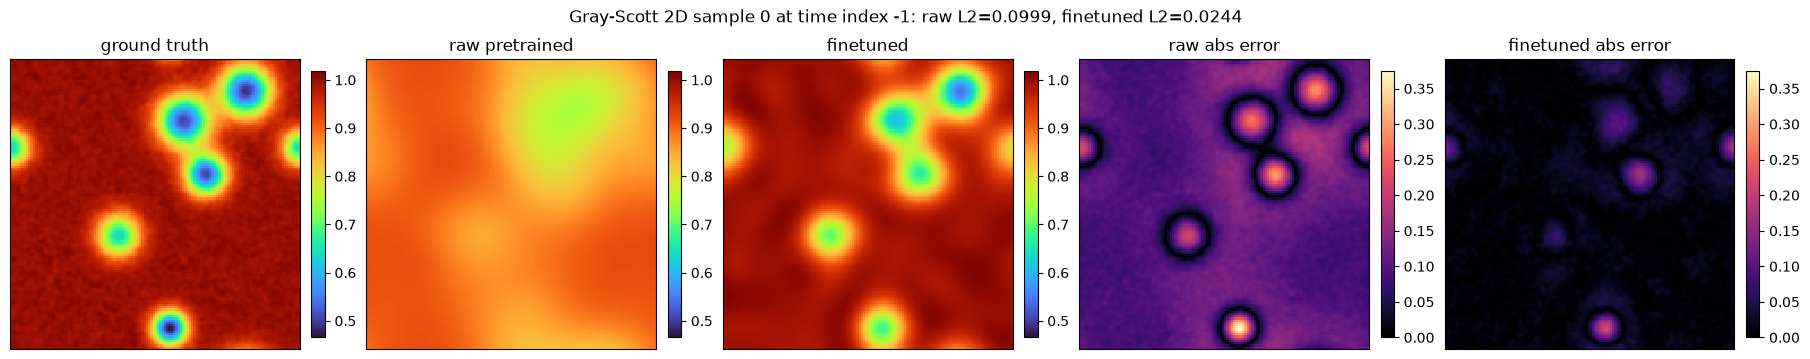

$u_t-D_u(u_{xx}+u_{yy})+uv^2-F(1-u)=0$
$v_t-D_v(v_{xx}+v_{yy})-uv^2+(F+k)v=0$
{'D_u': 1.9999999494757503e-05, 'D_v': 9.999999747378752e-06, 'F': 0.03500000014901161, 'k': 0.06499999761581421}


In [9]:
plot_sample_comparison(grayscott_demo, grayscott_raw_sample, grayscott_finetuned_sample, print_coefficients=True)


## Oldroyd-B/FENE-Style Finetuning Demo

This section is wired for the generated 2D periodic viscoelastic-flow experiment. Generate data with `python3 scripts/generate_viscoelastic2d_data.py`, then finetune with `config_path=configs/finetune/viscoelastic2d_model-L.yaml python3 train.py`. The demo entry auto-resolves `exp/finetune/viscoelastic2d/model-L/latest` to the newest timestamped run with a checkpoint and result CSV.

The modeled state is `(u, v, Cxx, Cxy, Cyy)`: Burgers-like momentum receives polymer-stress divergence, and the conformation tensor follows an Oldroyd-B equation with optional FENE-style trace correction `chi`.


| epoch | test_l2_mean | test_l2_max | train_l2_mean |
| --- | --- | --- | --- |
| 0 | 0.851206 | 2.29811 | 0.863098 |
| 5 | 0.508683 | 1.06206 | 0.482845 |
| 10 | 0.361682 | 1.0881 | 0.340849 |
| 15 | 0.320343 | 0.920868 | 0.276578 |
| 20 | 0.345742 | 0.895893 | 0.289069 |

| model | epoch | test_l2_mean | relative_improvement |
| --- | --- | --- | --- |
| raw pretrained | 0 | 0.851206 | 0 |
| best finetuned | 15 | 0.320343 | 0.62366 |

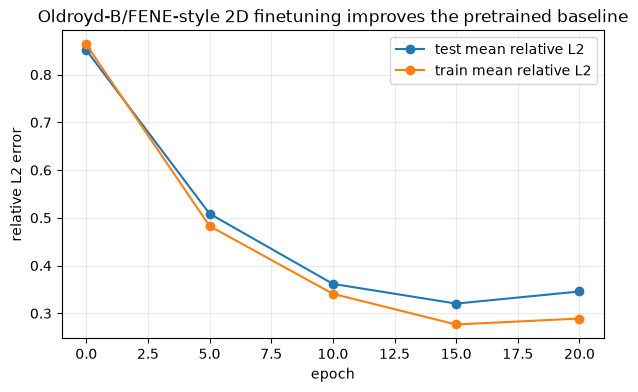

In [10]:
viscoelastic_demo = DEMOS["viscoelastic2d"]
viscoelastic_history, viscoelastic_summary = show_metric_history(viscoelastic_demo)


### Viscoelastic Live Held-Out Evaluation

Run this cell after the viscoelastic finetune has produced a checkpoint and result CSV.


In [11]:
viscoelastic_raw_scores, viscoelastic_raw_sample, viscoelastic_finetuned_scores, viscoelastic_finetuned_sample = evaluate_demo(viscoelastic_demo)


Oldroyd-B/FENE-style 2D model-L.pt:   0%|          | 0/1 [00:00<?, ?it/s, viscoelastic2d/viscoelastic2d]

Oldroyd-B/FENE-style 2D model_best.ckpt: 100%|██████████| 1/1 [03:19<00:00, 199.65s/it, viscoelastic2d/viscoelastic2d]


| metric | stat | raw pretrained | finetuned |
| --- | --- | --- | --- |
| relative L2 | count | 40 | 40 |
| relative L2 | mean | 0.851206 | 0.320343 |
| relative L2 | std | 0.604068 | 0.303315 |
| relative L2 | min | 0.150771 | 0.0254218 |
| relative L2 | median | 1.02869 | 0.295665 |
| relative L2 | max | 2.29811 | 0.920868 |
| relative L2 | improvement_vs_raw |  | 0.62366 |
| VRMSE | count | 40 | 40 |
| VRMSE | mean | 0.124587 | 0.0520205 |
| VRMSE | std | 0.0811634 | 0.063619 |
| VRMSE | min | 0.0227045 | 0.00450783 |
| VRMSE | median | 0.169017 | 0.0292572 |
| VRMSE | max | 0.266078 | 0.234855 |
| VRMSE | improvement_vs_raw |  | 0.582458 |
| residual RMAE | count | 8 | 8 |
| residual RMAE | mean | 0.199702 | 0.0947265 |
| residual RMAE | std | 0.00470092 | 0.01139 |
| residual RMAE | min | 0.188096 | 0.0779185 |
| residual RMAE | median | 0.200434 | 0.094506 |
| residual RMAE | max | 0.204038 | 0.108904 |
| residual RMAE | improvement_vs_raw |  | 0.52566 |

### Viscoelastic One-Sample Visual Comparison


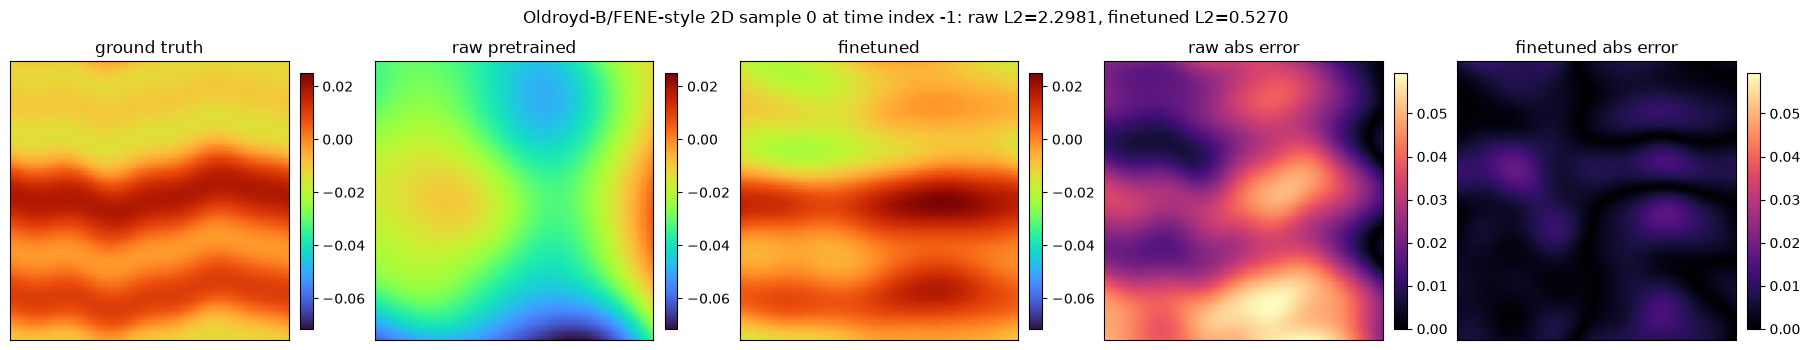

$u_t+uu_x+vu_y-\nu\Delta u-\beta(C_{xx,x}+C_{xy,y})=0$
$v_t+uv_x+vv_y-\nu\Delta v-\beta(C_{xy,x}+C_{yy,y})=0$
$C_t+\mathbf{u}\cdot\nabla C-C\nabla\mathbf{u}-(\nabla\mathbf{u})^TC+\lambda^{-1}[(1+\chi(\mathrm{tr}C-2))C-I]-\kappa\Delta C=0$
{'\\nu': 0.0005000000237487257, '\\beta': 0.0005000000237487257, '\\lambda': 4.0, '\\lambda^{-1}': 0.25, '\\kappa': 0.0005000000237487257, '\\chi': 0.009999999776482582}


In [12]:
plot_sample_comparison(viscoelastic_demo, viscoelastic_raw_sample, viscoelastic_finetuned_sample, print_coefficients=True)


## Takeaway

Use the logged curve for a lightweight posted demo, and use the live evaluation cells when you want reproducible before/after numbers from the checkpoints themselves. Gray-Scott and viscoelastic flow use the same path once their finetune artifacts are available. Their live tables now report relative L2, VRMSE, and residual RMAE, where residual RMAE is the mean absolute PDE residual evaluated directly on the model output, following the residual-error convention in the physics-informed diffusion model paper.

For Allen-Cahn, the raw pretrained output is visually low-contrast at the final plotted time, but it is not truly constant. A direct check on the first held-out sample gave global peak-to-peak range `0.359777`, final-frame peak-to-peak range `0.0228623`, and `constant_atol_1e-7 = False`.
